In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

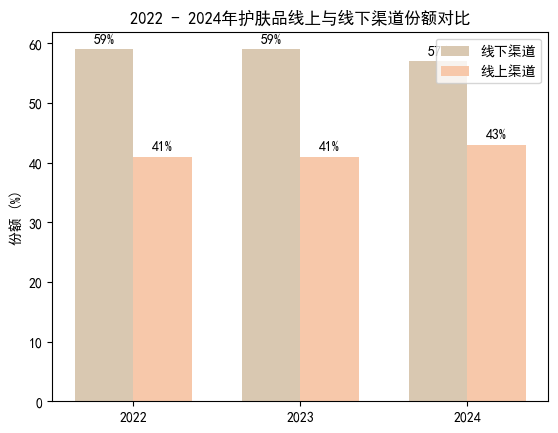

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = [2022, 2023, 2024]
# 线上渠道份额
online_shares = [41, 41, 43]
# 线下渠道份额（通过 100 - 线上渠道份额计算得出，因为整体为100% ）
offline_shares = [100 - x for x in online_shares]

x = np.arange(len(years))  # 柱状图 x 轴位置
width = 0.35  # 每个柱子的宽度

fig, ax = plt.subplots()
# 绘制线下渠道柱子
rects_offline = ax.bar(x - width/2, offline_shares, width, label='线下渠道', color='#D9C8B1')  
# 绘制线上渠道柱子
rects_online = ax.bar(x + width/2, online_shares, width, label='线上渠道', color='#F7C8AA')  

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(years)
# 设置 y 轴标签
ax.set_ylabel('份额 (%)')
# 设置标题
ax.set_title('2022 - 2024年护肤品线上与线下渠道份额对比')
# 添加图例
ax.legend()

# 在柱子上标注数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}%'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 数值标注位置偏移
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects_offline)
autolabel(rects_online)

plt.show()

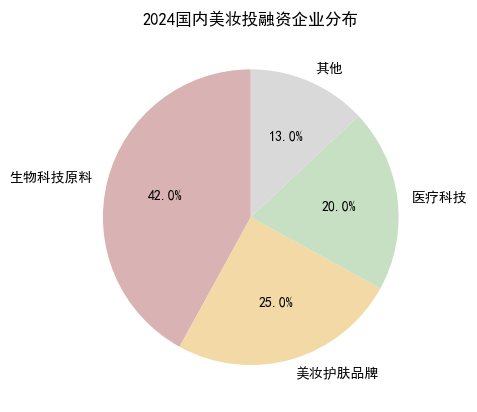

In [4]:
import matplotlib.pyplot as plt

# 数据
labels = ['生物科技原料', '美妆护肤品牌', '医疗科技', '其他']
sizes = [42, 25, 20, 13]  # 这里的数值为模拟，你可根据实际数据替换，保证总和为100
colors = ['#d9b3b3', '#f2d9a6', '#c7e0c3', '#d9d9d9']  # 自定义颜色

# 绘制饼图
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title('2024国内美妆投融资企业分布')

plt.show()

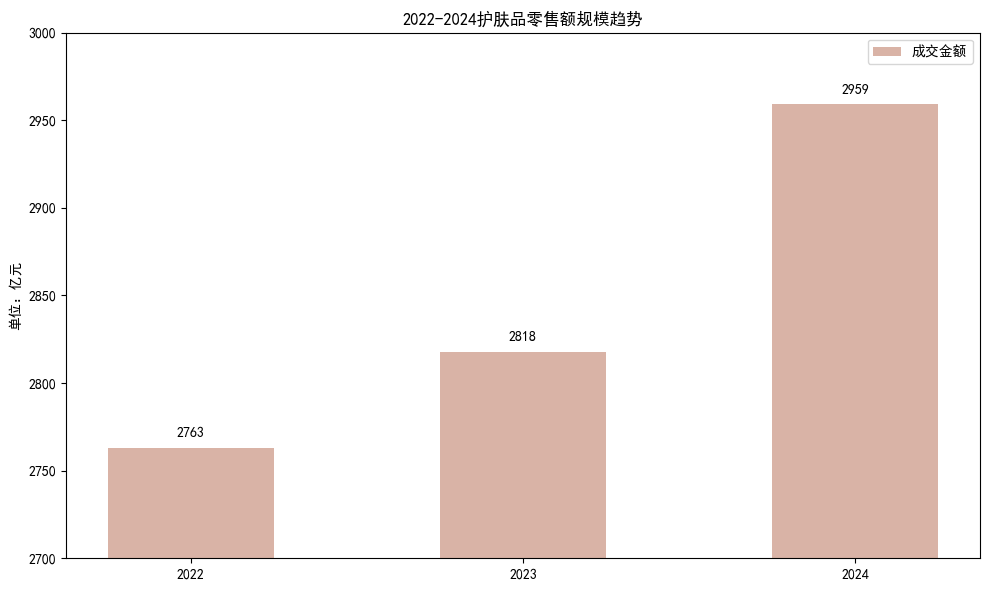

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = [2022, 2023, 2024]
# 成交金额（亿元）
amounts = [2763, 2818, 2959]

x = np.arange(len(years))
width = 0.5

fig, ax = plt.subplots(figsize=(10, 6))
rects = ax.bar(x, amounts, width, label='成交金额', color='#D9B3A6')

# 标注成交金额
for rect, amount in zip(rects, amounts):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 5,
            f'{amount}', ha='center', va='bottom')

# 设置Y轴范围以放大高度差距
ax.set_ylim(2700, 3000)

ax.set_ylabel('单位：亿元')
ax.set_title('2022-2024护肤品零售额规模趋势')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()

plt.tight_layout()
plt.show()    

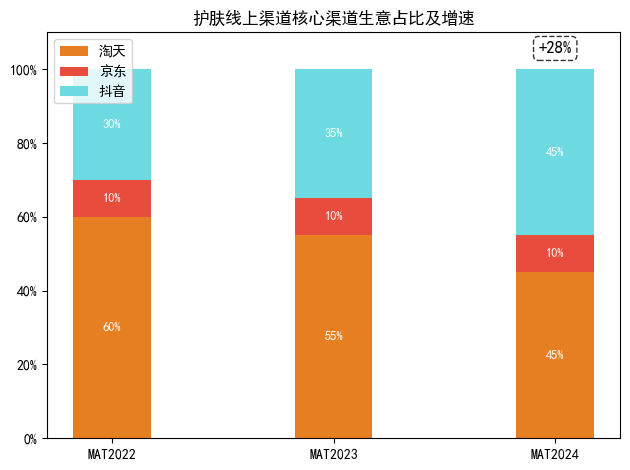

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 数据（示例，需按实际替换）
labels = ['MAT2022', 'MAT2023', 'MAT2024']
taobao = [60, 55, 45]  # 淘天占比（示例）
jingdong = [10, 10, 10]  # 京东占比（示例）
douyin = [30, 35, 45]  # 抖音占比（示例）

x = np.arange(len(labels))  # x轴位置
width = 0.35  # 柱状图宽度

fig, ax = plt.subplots()
# 绘制各渠道柱状图，注意bottom参数实现堆叠效果
rects_taobao = ax.bar(x, taobao, width, label='淘天', color='#E67E22')
rects_jingdong = ax.bar(x, jingdong, width, bottom=taobao, label='京东', color='#E74C3C')
rects_douyin = ax.bar(x, douyin, width, bottom=np.add(taobao, jingdong), label='抖音', color='#6DD9E0')

# 标注增速
ax.annotate('+28%', 
            xy=(2, 100),  # 将xy位置调整到第三个柱子的顶部
            xytext=(0, 10),  # 添加偏移量，使文本在柱子上方
            textcoords="offset points",
            ha='center', 
            va='bottom',
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", linestyle="--", alpha=0.8))

# 在每个柱子上标注数值
def add_labels(rects, bottom_values=None):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if bottom_values is not None:
            bottom = bottom_values[i]
        else:
            bottom = 0
        # 计算文本位置（柱子中间）
        y_position = bottom + height / 2
        # 添加数值标注
        ax.text(
            rect.get_x() + rect.get_width() / 2,  # x坐标：柱子中心
            y_position,                          # y坐标：柱子中间
            f'{height}%',                        # 显示的数值
            ha='center', va='center',            # 水平和垂直居中
            color='white', fontweight='bold',    # 白色文本，加粗
            fontsize=9                           # 字体大小
        )

# 为每个渠道添加标注
add_labels(rects_taobao)
add_labels(rects_jingdong, taobao)
add_labels(rects_douyin, np.add(taobao, jingdong))

# 设置x轴刻度与标签
ax.set_xticks(x)
ax.set_xticklabels(labels)
# 设置y轴范围
ax.set_ylim(0, 110)  # 增加y轴上限，避免文本被遮挡
# 添加y轴百分比刻度
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f'{i}%' for i in range(0, 101, 20)])
# 添加图例与标题
ax.legend()
ax.set_title('护肤线上渠道核心渠道生意占比及增速')

plt.tight_layout()  # 优化布局
plt.show()